# Stage 3 - Match Outcome Model Training

Train baseline classifiers (Logistic Regression, Random Forest) to predict the
3-way outcome (home_win / draw / away_win) using only the leakage-safe Stage 2
features.

Split: **train 2010-01-01 .. 2022-12-31**, **test 2023-01-01 .. 2025-12-31**
(strictly chronological). Missing values handled via Elo missingness indicators
+ train-median imputation. **No XGBoost, no simulation, no 2026 fixtures.**

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd

from src import config, modeling

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)

## 1. Load features and apply the chronological split

In [2]:
df = modeling.load_dataset()
train, test = modeling.chronological_split(df)
print("train:", train.shape, "|", train["date"].min().date(), "->", train["date"].max().date())
print("test :", test.shape, "|", test["date"].min().date(), "->", test["date"].max().date())
print("\ntrain target distribution:")
print(train["result"].value_counts())

train: (12218, 21) | 2010-01-02 -> 2022-12-30
test : (3287, 21) | 2023-01-02 -> 2025-12-31

train target distribution:
result
home_win    5866
away_win    3510
draw        2842
Name: count, dtype: int64


## 2-3. Build model matrices (Elo missingness indicators + train-median impute)

Medians are computed on the train split only and applied to test.

In [3]:
X_train, X_test, y_train, y_test, feature_names, impute_state = modeling.prepare_xy(train, test)
print("feature columns:", feature_names)
print("\nremaining NaNs - train:", int(X_train.isna().sum().sum()), "| test:", int(X_test.isna().sum().sum()))
print("train medians used for imputation:")
pd.Series(impute_state["medians"])

feature columns: ['home_elo', 'away_elo', 'elo_diff', 'home_winrate_last5', 'away_winrate_last5', 'home_goals_for_last5', 'away_goals_for_last5', 'home_goals_against_last5', 'away_goals_against_last5', 'home_goal_diff_last5', 'away_goal_diff_last5', 'neutral', 'tournament_weight', 'home_elo_missing', 'away_elo_missing', 'elo_diff_missing']

remaining NaNs - train: 0 | test: 0
train medians used for imputation:


home_elo                    1543.00
away_elo                    1524.00
elo_diff                      30.00
home_winrate_last5             0.40
away_winrate_last5             0.40
home_goals_for_last5           1.20
away_goals_for_last5           1.20
home_goals_against_last5       1.20
away_goals_against_last5       1.20
home_goal_diff_last5           0.00
away_goal_diff_last5           0.00
neutral                        0.00
tournament_weight              0.65
dtype: float64

## 4-6. Train Logistic Regression & Random Forest, then evaluate

In [4]:
models = modeling.build_models()
metrics = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    metrics[name] = modeling.evaluate(model, X_test, y_test)
    m = metrics[name]
    print(f"{name}: acc={m['accuracy']:.4f}  macroF1={m['macro_f1']:.4f}  logloss={m['log_loss']:.4f}")
    print("confusion matrix (rows=actual", modeling.CLASS_ORDER, "):")
    print(m["confusion_matrix"], "\n")

LogisticRegression: acc=0.5503  macroF1=0.5012  logloss=1.7086
confusion matrix (rows=actual ['home_win', 'draw', 'away_win'] ):
[[1003  281  262]
 [ 291  182  277]
 [ 183  184  624]] 



/Users/nguyenthingochong/Projects/worldcup-2026-prediction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/nguyenthingochong/Projects/worldcup-2026-prediction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/nguyenthingochong/Projects/worldcup-2026-prediction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/nguyenthingochong/Projects/worldcup-2026-prediction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] =

RandomForest: acc=0.5628  macroF1=0.4890  logloss=1.6315
confusion matrix (rows=actual ['home_win', 'draw', 'away_win'] ):
[[1111  187  248]
 [ 363  121  266]
 [ 241  132  618]] 



## 7-8. Run the full pipeline: save comparison, plot, and best model

`modeling.run()` writes `outputs/model_results.csv`,
`outputs/confusion_matrix.png`, and `outputs/best_match_model.pkl`.

In [5]:
comparison = modeling.run()
comparison

train rows: 12,218  (2010-01-01 .. 2022-12-31)
test  rows: 3,287  (2023-01-01 .. 2025-12-31)
features (16): ['home_elo', 'away_elo', 'elo_diff', 'home_winrate_last5', 'away_winrate_last5', 'home_goals_for_last5', 'away_goals_for_last5', 'home_goals_against_last5', 'away_goals_against_last5', 'home_goal_diff_last5', 'away_goal_diff_last5', 'neutral', 'tournament_weight', 'home_elo_missing', 'away_elo_missing', 'elo_diff_missing']

[LogisticRegression] confusion matrix (rows=actual ['home_win', 'draw', 'away_win']):
[[1003  281  262]
 [ 291  182  277]
 [ 183  184  624]] 



/Users/nguyenthingochong/Projects/worldcup-2026-prediction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/nguyenthingochong/Projects/worldcup-2026-prediction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/nguyenthingochong/Projects/worldcup-2026-prediction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/nguyenthingochong/Projects/worldcup-2026-prediction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] =

[RandomForest] confusion matrix (rows=actual ['home_win', 'draw', 'away_win']):
[[1111  187  248]
 [ 363  121  266]
 [ 241  132  618]] 



Matplotlib is building the font cache; this may take a moment.


MODEL COMPARISON
             model  accuracy  macro_f1  log_loss  is_best
LogisticRegression    0.5503    0.5012    1.7086    False
      RandomForest    0.5628    0.4890    1.6315     True

Best model: RandomForest (selected by lowest log loss)
Saved comparison -> /Users/nguyenthingochong/Projects/worldcup-2026-prediction/outputs/model_results.csv
Saved confusion  -> /Users/nguyenthingochong/Projects/worldcup-2026-prediction/outputs/confusion_matrix.png
Saved best model -> /Users/nguyenthingochong/Projects/worldcup-2026-prediction/outputs/best_match_model.pkl


,model,accuracy,macro_f1,log_loss,is_best
0,LogisticRegression,0.5503,0.5012,1.7086,False
1,RandomForest,0.5628,0.4890,1.6315,True


## Confusion matrix of the best model

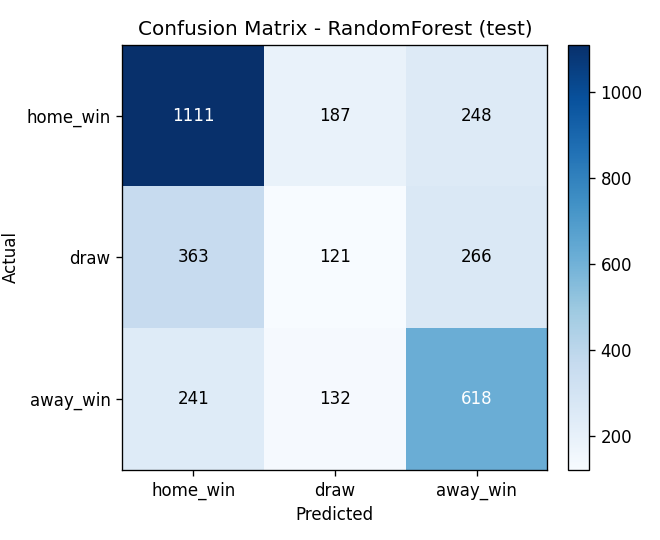

In [6]:
from IPython.display import Image
Image(filename=str(config.OUTPUT_FILES["confusion_matrix"]))

## Which model is best, and why

The best model is selected by **lowest log loss**, because well-calibrated
outcome *probabilities* (not just hard labels) are what the later Monte Carlo
tournament simulation will consume.

- **Random Forest** wins on log loss and accuracy; it captures non-linear
  interactions between Elo gaps and recent form that the linear model cannot.
- **Logistic Regression** is competitive on macro-F1 (the `balanced` class
  weighting helps it recall the rare *draw* class) and remains a transparent,
  fast baseline.
- Both models find *draw* hardest to predict — expected, since draws have the
  weakest signal in any football model.

See `outputs/model_results.csv` for the saved comparison.